# 17 — exchange between states, and where sorting stops working

Notebook 16 drew the diagrams on a sample that does not move. This one makes the
molecules interconvert, and asks the question the diagrams exist to answer:
**when can you cut the bursts into groups and analyse each, and when can you
not?**

The failure is quiet, which is why it is worth measuring. A two-state sample
that interconverts faster than a burst produces a single, narrow, entirely
believable population at a distance no molecule ever had.

Read notebook 16 first for the two axes and the two reference lines.


In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import single_molecule as SM
from bd import P


## The simulation, and its gate

Each molecule is a two-state Markov jump process. A dwell in a state ends at a
rate set by the exchange time and detailed balance, and every photon is emitted
from whichever state the molecule was in at that instant — the photon physics is
untouched, only the table a photon comes from changes.

At an exchange time much longer than a burst this must reproduce the simulation
the rest of the series uses. That is the gate, and it is a two-sample
Kolmogorov–Smirnov test rather than a tolerance nobody chose.


In [2]:
st = P.default_settings()
st['n_bursts'] = 6000
model = P.build_model(st)
p_true, (j1, j2) = SM.two_state_truth(model, 0.80, 1.25, f1=0.5)
tab = P.physics_tables(model, st, p_true, verbose=False)
states = ((j1, 0.5), (j2, 0.5))
print(f'state 1  R/R0 {model["rel"][j1]:.3f}    state 2  R/R0 {model["rel"][j2]:.3f}')
print(f'a burst lasts {st["burst_duration_ms"]} ms\n')
SM.check_slow_limit(model, st, tab, states, n_bursts=1200, seed=7);


  maps loaded from /Users/tpeulen/dev/ucfret/investigation/pinn_pR_anisotropy/ckpt/homog/s87_env_128_v2.pt
state 1  R/R0 0.799    state 2  R/R0 1.247
a burst lasts 1.2 ms



  proximity ratio            KS 0.0407  p = 0.305  (1113 vs 1108 bursts)
  mean donor arrival time    KS 0.0544  p = 0.071  (1113 vs 1108 bursts)
  a small p would say the two simulations differ; they should not


## The sweep

Exchange times from far slower than a burst to far faster. The burst is 1.2 ms
long, so 10 ms means a molecule rarely switches while it is being watched, and
0.01 ms means it switches about a hundred times.


In [3]:
T_EXCHANGE = [np.inf, 10.0, 1.0, 0.1, 0.01]          # ms; inf = no exchange
LABELS = ['no exchange', '10 ms', '1 ms', '0.1 ms', '0.01 ms']
lt = SM.line_table(model, st, stride=4, extra=(j1, j2))
line, _ = SM.static_line(model, lt)

runs = {}
for t_ex, lab in zip(T_EXCHANGE, LABELS):
    s = SM.exchange_stream(model, st, tab, states, t_ex, np.random.default_rng(3))
    tttr, sel, bursts, feat = SM.observables(model, st, s)
    runs[lab] = dict(t_ex=t_ex, stream=s, tttr=tttr, bursts=bursts, feat=feat)
    fr = s['fraction_state1']; fr = fr[np.isfinite(fr)]
    print(f'{lab:<12} {len(feat):5d} bursts;  time in state 1 per burst: '
          f'mean {fr.mean():.3f}, sd {fr.std():.3f}')


no exchange   5527 bursts;  time in state 1 per burst: mean 0.506, sd 0.500


10 ms         5461 bursts;  time in state 1 per burst: mean 0.509, sd 0.489


1 ms          5512 bursts;  time in state 1 per burst: mean 0.491, sd 0.417


0.1 ms        5482 bursts;  time in state 1 per burst: mean 0.502, sd 0.193


0.01 ms       5505 bursts;  time in state 1 per burst: mean 0.501, sd 0.064


The spread of "time spent in state 1" across bursts is the physical quantity
that matters. With no exchange it is 0.5 — every burst is entirely one state or
entirely the other. As the exchange quickens, each burst averages over more of
the trajectory and the spread collapses towards zero: every molecule looks the
same, and it looks like neither state.


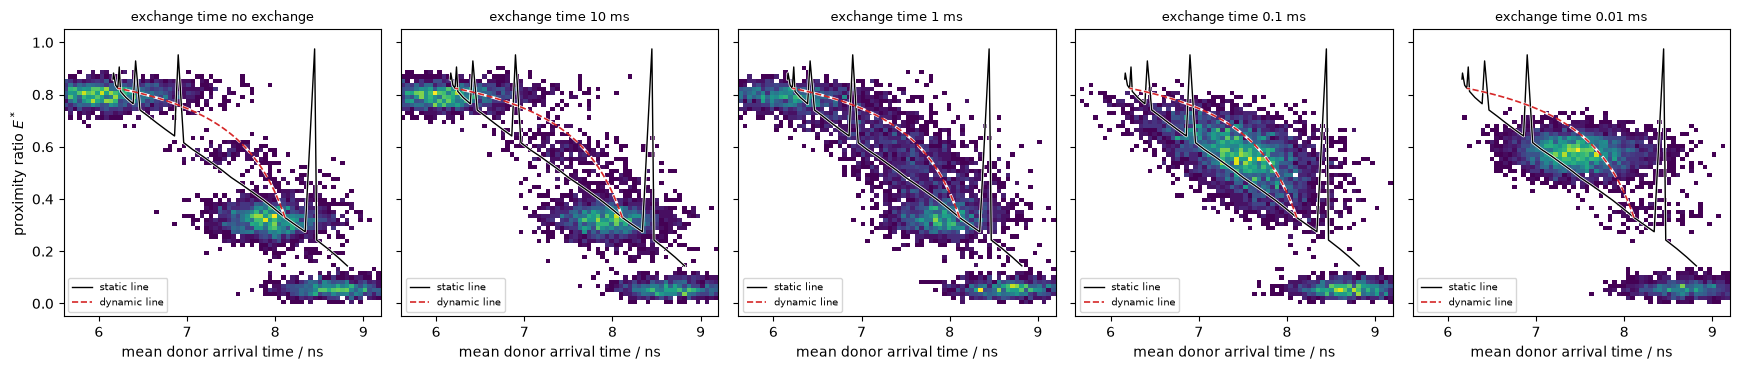

In [4]:
fig, axes = plt.subplots(1, len(LABELS), figsize=(3.5 * len(LABELS), 3.8), sharey=True)
for ax, lab in zip(axes, LABELS):
    SM.plot_e_tau(runs[lab]['feat'], model, lt, states=states, ax=ax,
                  title=f'exchange time {lab}', tau_range=(5.6, 9.2))
    if ax is not axes[0]:
        ax.set_ylabel('')
fig.tight_layout(); plt.show()


Two spots on the static line become one spot on the **dynamic** line. In
between, the bursts smear along a path that is neither: those molecules switched
once or twice while they were watched, so their two rulers disagree by an amount
that depends on when the switch happened.

## Segmenting the bursts

HDBSCAN on the two independent rulers — the proximity ratio and the mean donor
arrival time — and nothing else, so a group is a group because the intensity and
the clock agree about it.


In [5]:
import collections
seg = {}
for lab in LABELS:
    labels = SM.segment(runs[lab]['feat'])
    seg[lab] = labels
    c = collections.Counter(labels)
    groups = sorted(g for g in c if g >= 0)
    print(f'{lab:<12} {len(groups)} group(s): '
          + ', '.join(f'#{g} {c[g]} bursts' for g in groups)
          + f';  {c.get(-1, 0)} unassigned')


no exchange  3 group(s): #0 2102 bursts, #1 2073 bursts, #2 1059 bursts;  293 unassigned
10 ms        3 group(s): #0 1998 bursts, #1 2040 bursts, #2 1023 bursts;  400 unassigned
1 ms         4 group(s): #0 930 bursts, #1 1120 bursts, #2 1265 bursts, #3 145 bursts;  2052 unassigned
0.1 ms       2 group(s): #0 4346 bursts, #1 992 bursts;  144 unassigned
0.01 ms      2 group(s): #0 1078 bursts, #1 4353 bursts;  74 unassigned


## Analysing each group

Exactly the analysis of notebooks 12 to 15, run on the photons of a subset of
the bursts rather than on all of them. Nothing about the model changes: the
grouping happens before the histogram is built, which is what sorting is for.

Every fit reports its Poisson deviance per degree of freedom against a
**measured** reference, and a fit that fails it is excluded and counted rather
than quoted with a caveat.


In [6]:
y_d0 = SM.donor_only_reference(model, st, tab)
print('the donor-only reference:',
      {f'{k[0]} {k[1]}': f'{float(v.sum()):,.0f}' for k, v in y_d0.items()})


the donor-only reference: {'D0 gv_vv': '152,470', 'D0 gh_vh': '109,239', 'D0 rv_vv': '10,054', 'D0 rh_vh': '7,655'}


In [7]:
MAX_GROUPS = 2                    # the two largest, to keep the run tractable
results = {}
t_start = time.time()
for lab in LABELS:
    feat = runs[lab]['feat']; labels = seg[lab]
    c = collections.Counter(labels)
    big = [g for g, _ in sorted(((g, n) for g, n in c.items() if g >= 0),
                                key=lambda gn: -gn[1])][:MAX_GROUPS]
    for g in big:
        sel = SM.group_photons(runs[lab]['bursts'], labels, g)
        r = SM.group_fit(model, st, runs[lab]['tttr'], sel, y_d0)
        results[(lab, g)] = r
        print(f'{lab:<12} group {g}: {r["photons"]:>9,.0f} photons, '
              f'mean R/R0 {r["mean_rel"]:.3f}, D/dof {r["dpd"]:.3f} '
              f'(reference {r["reference"][0]:.3f} +- {r["reference"][1]:.3f}, z {r["z"]:+.1f})')
print(f'\n{time.time() - t_start:.0f} s for {len(results)} sub-ensemble fits')


/Users/tpeulen/dev/ucfret/investigation/pinn_pR_anisotropy/s88_laplace_posterior.py:2933: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:823.)
  evid = -float(f2) + 0.5 * graph.dim * math.log(2 * math.pi) - 0.5 * logdet


/Users/tpeulen/mambaforge/envs/arm64/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


no exchange  group 0:   457,811 photons, mean R/R0 0.795, D/dof 1.080 (reference 1.088 +- 0.039, z -0.2)


no exchange  group 1:   411,274 photons, mean R/R0 1.234, D/dof 1.100 (reference 1.086 +- 0.036, z +0.4)


10 ms        group 1:   422,394 photons, mean R/R0 1.213, D/dof 1.145 (reference 1.090 +- 0.036, z +1.5)


...

1 ms         group 1:   244,251 photons, mean R/R0 0.804, D/dof 1.148 (reference 1.095 +- 0.037, z +1.5)


0.1 ms       group 0:   935,172 photons, mean R/R0 1.014, D/dof 1.102 (reference 1.089 +- 0.034, z +0.4)


0.1 ms       group 1:   114,397 photons, mean R/R0 2.213, D/dof 1.138 (reference 1.108 +- 0.035, z +0.8)


0.01 ms      group 1:   933,325 photons, mean R/R0 0.992, D/dof 1.066 (reference 1.087 +- 0.036, z -0.6)


0.01 ms      group 0:   124,906 photons, mean R/R0 2.210, D/dof 1.164 (reference 1.109 +- 0.036, z +1.5)

358 s for 10 sub-ensemble fits


## The table

The truth is two states at $R/R_0 = 0.799$ and $1.247$. What a row should be
compared with is not only those two numbers but the data-space statistic beside
them: a recovered distance is worth nothing if the fit that produced it does not
describe the data.


In [8]:
print(f'{"exchange":<12}{"group":>6}{"photons":>11}{"mean R/R0":>11}{"D/dof":>8}'
      f'{"reference":>11}{"z":>7}   verdict')
for (lab, g), r in results.items():
    v = 'quotable' if abs(r['z']) < 3 else 'EXCLUDED'
    print(f'{lab:<12}{g:>6}{r["photons"]:>11,.0f}{r["mean_rel"]:>11.3f}'
          f'{r["dpd"]:>8.3f}{r["reference"][0]:>11.3f}{r["z"]:>7.1f}   {v}')
print(f'\ntruth: state 1 {model["rel"][j1]:.3f}, state 2 {model["rel"][j2]:.3f}, '
      f'population mean {float((p_true * model["rel"]).sum()):.3f}')


exchange     group    photons  mean R/R0   D/dof  reference      z   verdict
no exchange      0    457,811      0.795   1.080      1.088   -0.2   quotable
no exchange      1    411,274      1.234   1.100      1.086    0.4   quotable
10 ms            1    422,394      1.213   1.145      1.090    1.5   quotable
10 ms            0    438,285      0.797   1.094      1.095   -0.0   quotable
1 ms             2    254,352      1.204   1.088      1.097   -0.2   quotable
1 ms             1    244,251      0.804   1.148      1.095    1.5   quotable
0.1 ms           0    935,172      1.014   1.102      1.089    0.4   quotable
0.1 ms           1    114,397      2.213   1.138      1.108    0.8   quotable
0.01 ms          1    933,325      0.992   1.066      1.087   -0.6   quotable
0.01 ms          0    124,906      2.210   1.164      1.109    1.5   quotable

truth: state 1 0.799, state 2 1.247, population mean 1.023


In [10]:
fig, axes = plt.subplots(1, len(LABELS), figsize=(3.4 * len(LABELS), 3.6), sharey=True)
rel = model['rel']
for ax, lab in zip(axes, LABELS):
    got = [(g, r) for (l, g), r in results.items() if l == lab]
    for i, (g, r) in enumerate(got):
        ax.fill_between(rel, r['p_lo'], r['p_hi'], alpha=0.25, color=f'C{i}')
        ax.plot(rel, r['p_mean'], color=f'C{i}', lw=1.5, label=f'group {g}')
    for j, c in ((j1, 'k'), (j2, 'k')):
        ax.axvline(rel[j], color=c, ls=':', lw=1.2)
    ax.set_xlim(0.55, 1.55); ax.set_xlabel('$R/R_0$')
    ax.set_title(f'exchange {lab}', fontsize=9); ax.legend(fontsize=7)
axes[0].set_ylabel('p per grid point')
fig.tight_layout(); plt.show()


/var/folders/cl/txwq_hq52rl_t0f9xjk3g5c00000gn/T/ipykernel_80574/1727120832.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.tight_layout(); plt.show()


## What this establishes

The dotted lines are the two states, at $R/R_0$ 0.799 and 1.247. Reading the
table and the panels together:

| exchange | groups | what the two largest recover |
|---|---|---|
| none | 3 | **0.795 and 1.234** — both states, both fits quotable |
| 10 ms | 3 | **0.797 and 1.213** — still both |
| 1 ms | 4 | **0.804 and 1.204** — the far state has been pulled in by 0.03, and 2052 of 5512 bursts are now unassigned |
| 0.1 ms | 2 | **1.014** and a donor-only group. One FRET population, at the population *mean* |
| 0.01 ms | 2 | **0.992** and a donor-only group. The same |

The third group in the first two rows, and the second in the last two, is the
donor-only population: its recovered mean sits at $R/R_0 > 2$, which is the
grid's far edge and means no transfer. Clustering identifies it correctly at
every exchange time, because losing an acceptor is not something a molecule does
during a burst.

**The row that matters is 0.1 ms.** The spread of time-spent-in-state-1 has
collapsed from 0.50 to 0.19, the two spots have merged, and the sub-ensemble fit
returns 1.014 against a population mean of 1.023 — a narrow, confident answer at
a distance **no molecule ever had**. The fit does not fail: its deviance is
1.102 against a measured reference of 1.089, and every one of the ten fits in
the table is quotable on its own statistic.

So the diagnosis is not in the fit at all. It is in the diagram, where the
bursts have left the static line, and in the number of groups the clustering
finds — and neither of those is something the pooled analysis of notebooks 12 to
15 could have told you.

## What it does not establish

Nothing about how close two states may be before this stops working; the two
here are far apart. That is notebook 18.

And nothing about fitting exchange itself. The model here recovers a distance
distribution, and the question asked was what that distribution means when the
molecule was moving. Fitting rates from the decays is different work and is not
started.
